In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import geopandas as gpd
import matplotlib.pyplot as plt
import os

PATH_TO_MINIMUM_WAGE = "/kaggle/input/datasets/mafaqbhatti/global-minimum-wage-data-170-countries/"
PATH_TO_GLOBAL_MAP = "/kaggle/input/datasets/jethrotongowona/naturalearth/ne_110m_admin_0_countries.shp"

# Importação dos Dados

In [2]:
# Importando os dados sem burocracia
data = pd.read_csv(PATH_TO_MINIMUM_WAGE + "global_minimum_wage.csv")
data

,Country,Minimum_Wage_Local,Currency,Wage_Period,Minimum_Wage_USD_Monthly,Year,Notes
0,Afghanistan,NaN,AFN,NaN,NaN,2025,No statutory minimum wage
1,Albania,40000.0,ALL,Monthly,444.0,2025,National minimum wage
2,Algeria,20000.0,DZD,Monthly,149.0,2025,National minimum wage (SNMG)
3,Andorra,1376.0,EUR,Monthly,1502.0,2025,National minimum wage
4,Angola,70000.0,AOA,Monthly,76.0,2025,National minimum wage
...,...,...,...,...,...,...,...
181,Venezuela,130.0,VES,Monthly,3.0,2025,Hyperinflation severely impacts real value
182,Vietnam,4960000.0,VND,Monthly,194.0,2025,Region 1 minimum wage (Hanoi/HCMC)
183,Yemen,NaN,YER,NaN,NaN,2025,Conflict-affected; minimum wage not enforced
184,Zambia,3600.0,ZMW,Monthly,127.0,2025,National minimum wage


# Limpando os Dados

In [3]:
# Retiramos colunas inúteis
data = data.drop(["Minimum_Wage_Local", "Currency", "Notes"], axis=1)

# Limpando dados
data = data[data["Wage_Period"] == "Monthly"].drop("Wage_Period", axis=1)
data = data[data["Year"] == 2025].drop("Year", axis=1)
data.dropna(inplace=True)
data

,Country,Minimum_Wage_USD_Monthly
1,Albania,444.0
2,Algeria,149.0
3,Andorra,1502.0
4,Angola,76.0
6,Argentina,934.0
...,...,...
178,Uruguay,552.0
179,Uzbekistan,82.0
181,Venezuela,3.0
182,Vietnam,194.0


# Extraindo Informações Válidas

In [4]:
data = data.sort_values("Minimum_Wage_USD_Monthly", ascending=False)
data

,Country,Minimum_Wage_USD_Monthly
93,Luxembourg,2876.00
15,Belgium,2259.00
55,France,1965.00
140,San Marino,1527.00
76,Israel,1526.00
...,...,...
30,Central African Republic,14.00
57,Georgia,7.00
41,Democratic Republic of Congo,5.00
181,Venezuela,3.00


# Apresentando de forma Inteligente

In [5]:
global_map = gpd.read_file(
    PATH_TO_GLOBAL_MAP
)

global_with_data = global_map.merge(
    data,
    left_on="ADMIN", # Unimos a partir do nome dominante
    right_on="Country", # Coluna de Nomes em nosso Dataframe
    how="left", # Unimos de forma a manter todos os países
)

global_with_data.head()
# Note que os países que não temos informações, estarão como NaN.

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,Country,Minimum_Wage_USD_Monthly
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",NaN,NaN
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",NaN,NaN
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",NaN,NaN
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025...",NaN,NaN
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312...",NaN,NaN


### Apresentando um Mapa Global com as informações disponíveis

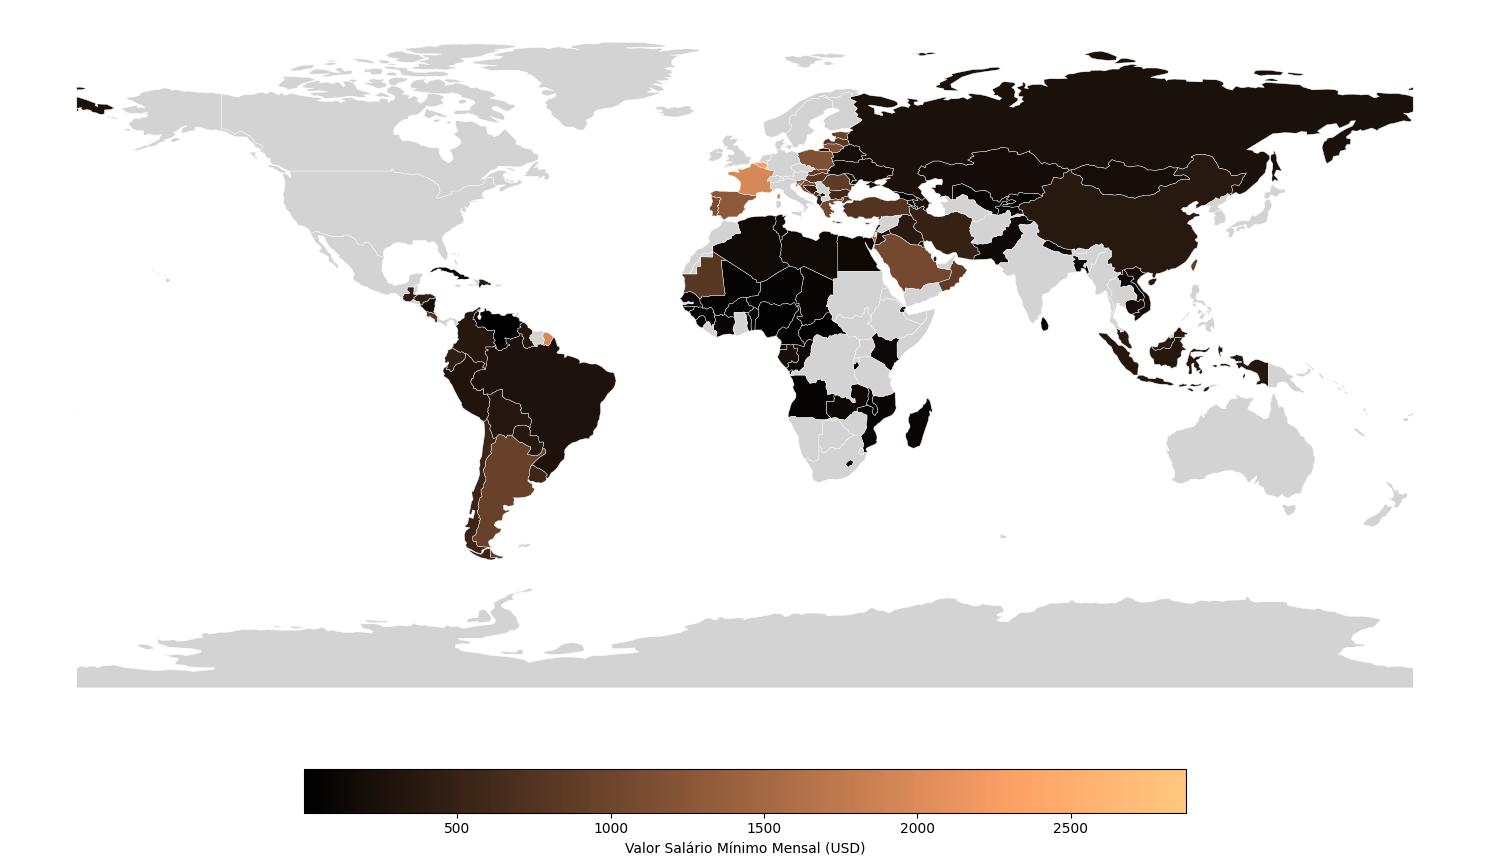

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plotamos mapa com cores relacionadas aos valores
global_with_data.plot(
    column="Minimum_Wage_USD_Monthly", # coluna com os valores
    cmap='copper',                     # mapa de cores
    legend=True,                       # mostrar barra de cores
    legend_kwds={
        'label': 'Valor Salário Mínimo Mensal (USD)',        # título da barra
        'orientation': 'horizontal',  # horizontal ou vertical
        'shrink': 0.6,           # tamanho da barra
        'pad': 0.05              # espaçamento
    },
    missing_kwds={
        'color': 'lightgray',    # cor para países sem dados
        'label': 'Sem dados'
    },
    edgecolor='white',           # borda dos países
    linewidth=0.3,               # espessura da borda
    ax=ax
)

# Configurar o gráfico
ax.set_axis_off() 
plt.tight_layout()
plt.show()                              

### Apresentando um Gráfico de Barras para demonstrar desigualdade

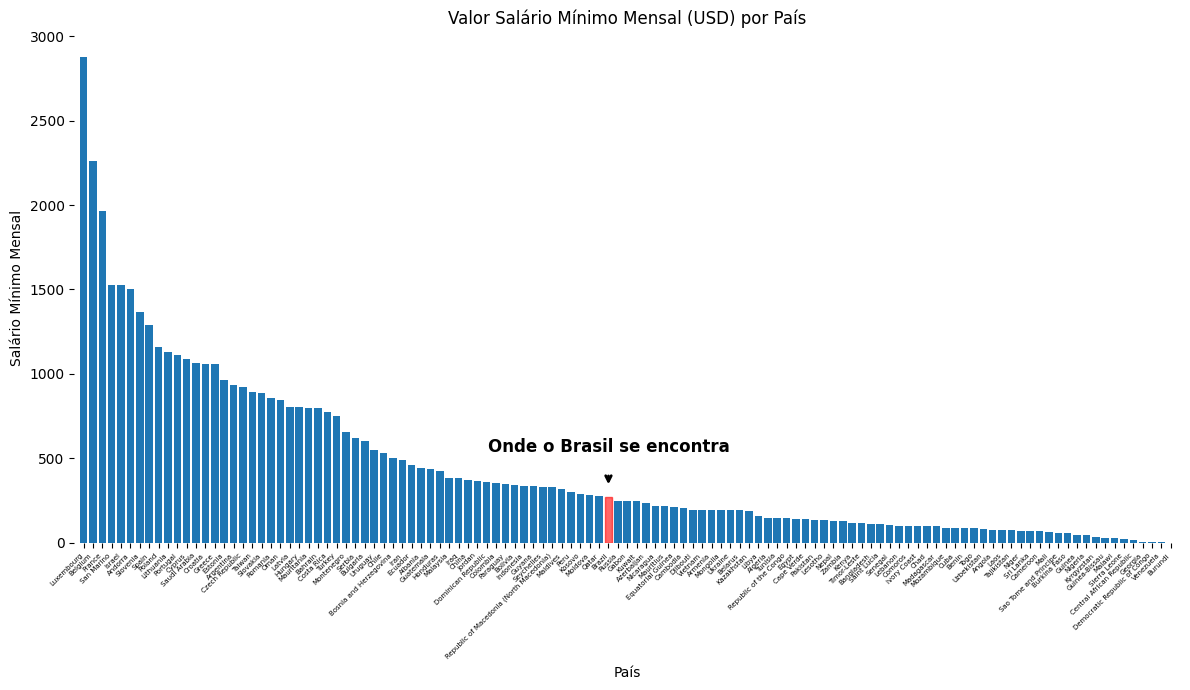

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

# Como informação principal, adicionamos as barras
barras = ax.bar(data["Country"], data["Minimum_Wage_USD_Monthly"], width=0.8)
idx_brazil = data["Country"].tolist().index("Brazil")

# Modificamos a cor da barra
barras[idx_brazil].set_color('red')
barras[idx_brazil].set_alpha(0.6)  

# Coordenadas da seta
x_seta = idx_brazil  # posição x da barra
y_seta = data["Minimum_Wage_USD_Monthly"][idx_brazil] + 150  # um pouco acima da barra
y_alvo = data["Minimum_Wage_USD_Monthly"][idx_brazil] + 100  # ponta da seta (topo da barra)

# annotate com seta
ax.annotate(
    "",  # texto vazio (só a seta)
    xy=(x_seta, y_alvo),           # ponto final (ponta da seta)
    xytext=(x_seta, y_seta),       # ponto inicial (cauda da seta)
    arrowprops=dict(
        arrowstyle='->',            # estilo da seta
        color='black',              # cor
        lw=2,                       # espessura da linha
        shrinkA=0,                   # não encolher na cauda
        shrinkB=0                    # não encolher na ponta
    )
)

ax.text(
    x_seta,                          # posição x
    y_alvo + 170,   # posição y (acima da barra)
    "Onde o Brasil se encontra",  # texto
    ha='center',                      # alinhamento horizontal
    va='bottom',                      # alinhamento vertical
    fontsize=12,                      # tamanho da fonte
    fontweight='bold',                 # negrito
)

# Fazemos ajustes gerais no gráfico
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.title("Valor Salário Mínimo Mensal (USD) por País")
plt.xlabel('País')
plt.xticks(rotation=45, ha='right', fontsize=5) 
plt.ylabel('Salário Mínimo Mensal')
plt.tight_layout() 
plt.margins(x=0.005)
plt.show()